# Stock Price Prediction using HMM, LSTM, ARIMA, and RNN

In this notebook, we will predict stock prices using various methods including Hidden Markov Model (HMM), Long Short-Term Memory (LSTM), AutoRegressive Integrated Moving Average (ARIMA), and Recurrent Neural Network (RNN). We will compare the performance of these models using various error metrics.


In [34]:
# Import necessary libraries for data manipulation, model building, and evaluation

# from hmmlearn import hmm
import numpy as np
# import pandas as pd
import matplotlib.pyplot as plt
# import yfinance as yf

from evaluationFuncs import ape, aae, arpe, rmse, direction_accuracy

from modelFuncs import dataExtracterMonths, HMMPricePredictor

## Load and Prepare Data

In this section, we load the data and preprocess it for modeling.


In [52]:
# Print the monthly data
# obs = dataExtracterMonths('NVO', '2002-01-01', '2026-01-01')
ticker = 'ED'
obs = dataExtracterMonths(ticker, '1987-01-01', '2026-01-01')

[*********************100%***********************]  1 of 1 completed

The dataset has observations across 468 months


## Hidden Markov Model (HMM)

We will implement the HMM to predict future stock prices.

In [53]:
cutoff = 200
data = obs[:cutoff]
dates = obs['Date'][cutoff:]
data = data[data.columns[1:5]]
obs = obs[obs.columns[1:5]]

In [54]:
# print(obs)
# print(data)

In [56]:
hmm_price, close = HMMPricePredictor(data, obs, window_size=200, Ncomp=5)

## Plot Predictions

Now, we plot the predictions from all models alongside the actual observed prices.


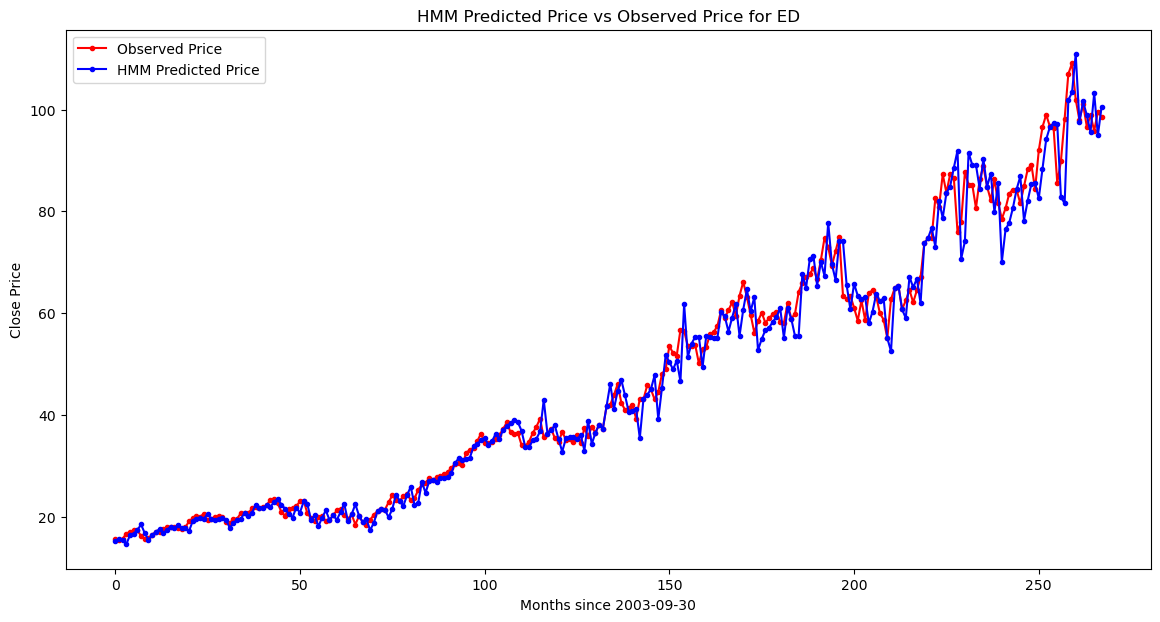

In [57]:
fig, ax = plt.subplots(figsize=(14, 7))

# Plot actual prices for the corresponding period
ax.plot(close, marker='.', label='Observed Price', color='red')
ax.plot(hmm_price, marker='.', label='HMM Predicted Price', color='blue')
ax.set_ylabel("Close Price")
ax.set_xlabel(f"Months since {dates[cutoff]}")
ax.legend();
ax.set_title(f"HMM Predicted Price vs Observed Price for {ticker}");

## Model evaluation

Finally, we will evaluate the performance of each model using metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Direction Accuracy.

In [58]:
# Convert lists to numpy arrays
close = np.array(close)
hmm_price = np.array(hmm_price)

ape_hmm = ape(close, hmm_price)
aae_hmm = aae(close, hmm_price)
arpe_hmm = arpe(close, hmm_price)
rmse_hmm = rmse(close, hmm_price)
print("Absolute Percentage Error for HMM: ", ape_hmm)
print("Average Absolute Error for HMM: ", aae_hmm)
print("Average Relative Percentage Error for HMM: ", arpe_hmm)
print("Root Mean Squared Error for HMM: ", rmse_hmm)

Absolute Percentage Error for HMM:  0.05061121951133057
Average Absolute Error for HMM:  2.3906529625849933
Average Relative Percentage Error for HMM:  0.008920346875317139
Root Mean Squared Error for HMM:  3.692164149492364


In [59]:
direction_accuracy_hmm = direction_accuracy(close, hmm_price)
print("Direction Accuracy for HMM: ", direction_accuracy_hmm)

Direction Accuracy for HMM:  0.5131086142322098
